(20, 4)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


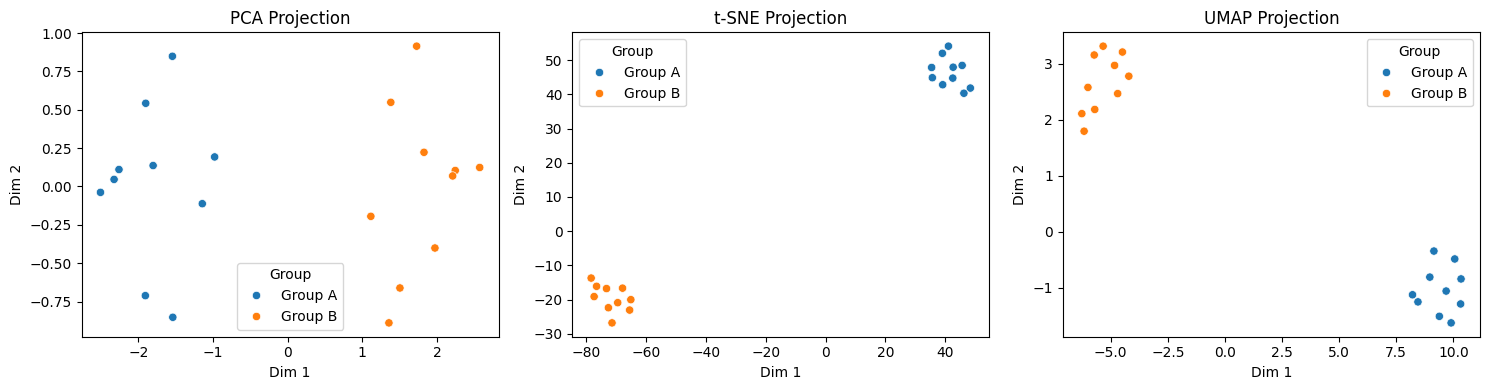

In [17]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

#scaling because never scaled
scalar=StandardScaler()
# --- DATASET GENERATION (Do not change) ---
np.random.seed(42)
data = np.random.randn(20, 4)
data[10:, :] += 3.5 # Create 2 groups
labels = ['Group A']*10 + ['Group B']*10
df = pd.DataFrame(data, columns=['F1', 'F2', 'F3', 'F4'])
X_scaled = scalar.fit_transform(df)
# PCA
pca_res = PCA(n_components=2).fit_transform(X_scaled)
#print(pca_res)
#TSNE
print(df.shape)
#2nd error: tsne perplexity was greater than number of rows
tsne_res = TSNE(n_components=2, perplexity=5,
random_state=42).fit_transform(X_scaled)
#print(tsne_res)
# UMAP
umap_res = umap.UMAP(n_components=2, n_neighbors=5,
random_state=42).fit_transform(X_scaled)
#print(umap_res)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, results):
  plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
  plot_df['Group'] = labels
  sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', hue='Group', ax=ax)
  ax.set_title(f"{title} Projection")
plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
from sklearn.datasets import load_iris

# Load iris with as_frame=True
iris = load_iris(as_frame=True)
df = iris.frame

# Alternatively, build the DataFrame manually
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df['target'] = iris_raw.target
df['species'] = df['target'].map(dict(enumerate(iris_raw.target_names)))

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


In [31]:
feats=['sepal length (cm)', 'sepal width (cm)']
complete_feats=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

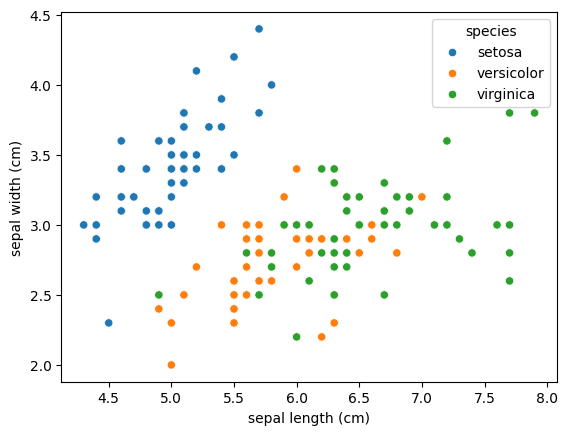

In [30]:
import seaborn as sns
sns.scatterplot(data=df, x=feats[0], y=feats[1], hue='species')
plt.show()

(150, 6)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


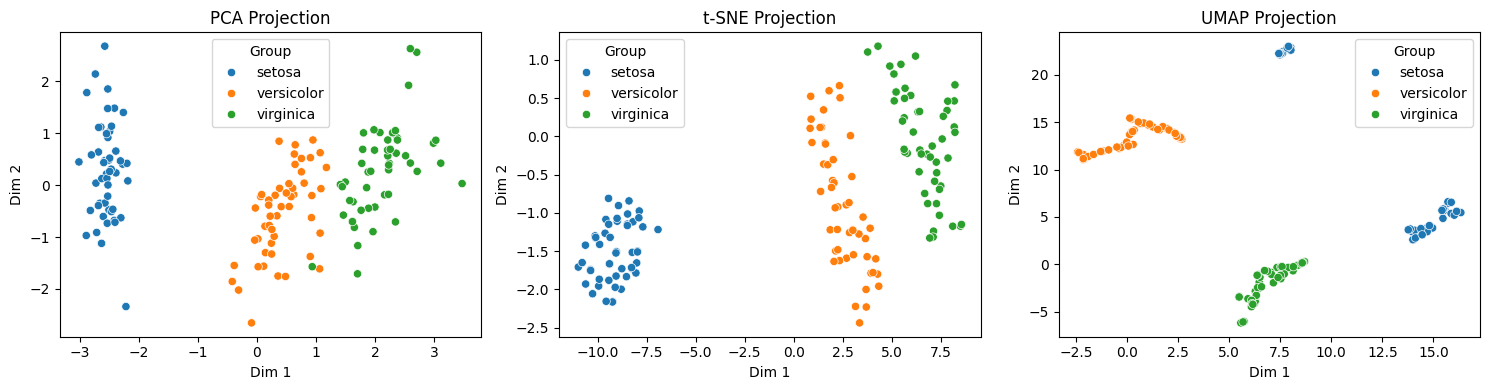

In [37]:
#now plotting using pca, tsne, and umap
#scaling because never scaled
features = df.drop(columns=["species"])
labels = df["species"]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(features)

# PCA
pca_res = PCA(n_components=2).fit_transform(X_scaled)
#print(pca_res)
#TSNE
print(df.shape)
#2nd error: tsne perplexity was greater than number of rows
tsne_res = TSNE(n_components=2, perplexity=50,
random_state=42).fit_transform(X_scaled)
#print(tsne_res)
# UMAP
umap_res = umap.UMAP(n_components=2, n_neighbors=5,
random_state=42).fit_transform(X_scaled)
#print(umap_res)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
results = [('PCA', pca_res), ('t-SNE', tsne_res), ('UMAP', umap_res)]
for ax, (title, res_data) in zip(axes, results):
  plot_df = pd.DataFrame(res_data, columns=['Dim 1', 'Dim 2'])
  plot_df['Group'] = labels
  sns.scatterplot(data=plot_df, x='Dim 1', y='Dim 2', hue='Group', ax=ax)
  ax.set_title(f"{title} Projection")
plt.tight_layout()
plt.show()
